# Semi-Supervised Learning (SSL)


SSL studies how to learn from both labeled and unlabeled data, which can be useful when data is abundant but the resources to label them are limited.

In this exercise, you will:

* Given a simulated dataset with both labeled and unlabeled data, build a similarity graph and use the Harmonic Function Solution (HSF) to predict the labels of the unlabeled data;
* Use HSF for face recognition, given a fixed dataset;
* Implement an online version of HSF to label images as they appear in real time.

## 1. Harmonic Function Solution

Let $G = (V, E)$ be a weighted undirected graph where $V = \{x_1, \ldots, x_n \}$ is the vertex set and $E$ is the edge set. Each edge $e_{ij} \in E$ has a weight $w_{ij}$ and, if there is no edge between $x_i$ and $x_j$, then $w_{ij}=0$.

Let $|V| = n$ be the total number of nodes. Only a subset of the nodes $S \subset V$ with cardinality $|S| = l$ is labeled, and the remaining $u = n - l$ nodes are placed in the subset $T = V \setminus S$. 

Our goal is to predict the labels of the vertices in $T$ using the structure of the graph. Since we believe that nodes close in the graph should have similar labels, we would like to have each node surrounded by a majority of nodes with the same label. In order to do so, we impose that the labeling vector $f \in \mathbb{R}^n$ must be an **harmonic function** on the graph, that is:

$$
f_i = \frac{\sum_{j} w_{ij} f_j}{\sum_{j} w_{ij}},  \forall i \in T
$$

One interpretation for this constraint is that $w_{ij}$ represents the tendency of moving from node $x_i$ to node $x_j$, the stationary distribution of the transition matrix $P(j|i) = \tfrac{w_{ij}}{\sum_{k} w_{ik}}$  is a valid solution to our problem. 

### Hard HFS

It can be shown that $f$ is harmonic if and only if $(Lf)_T = 0$, where $(Lf)_T$ is the vector containing the values of $Lf$ for the nodes in the set $T$, and $L$ is the graph Laplacian. 

Hence, the harmonic function solution to the SSL problem is the solution to the following optimization problem:

$$
\min_{f \in \mathbb{R}^n}  f^T L f  
\quad \text{s.t} \quad
y_i = f(x_i) \quad \forall x_i \in S
$$
where $y_i$ are the labels available for the vertices $x_i \in S$. This gives us:

$$
f_T = L_{TT}^{-1}(W_{TS}f_S) = - L_{TT}^{-1}(L_{TS}f_S) 
$$

### Soft HFS

If the labels are noisy, we might need to replace the "hard" constraint of the optimization problem above by a "soft" constraint. Let $C$ be a diagonal matrix such that $C_{ii} = c_l$ for labeled examples and $C_{ii} = c_u$ otherwise. Also, define $y_i = 0$ for unlabeled examples, that is, for $x_i \in T$. 

The soft HFS objective function is

$$
\min_{f\in\mathbb{R}^n} (f-y)^T C (f-y) + f^T L f
$$
whose solution is 

$$
f^* = (C^{-1}L+I)^{-1}y
$$


### Implementation

Implement hard and soft HFS in the function `compute_hfs`. Complete the function `two_moons_hfs` to test your implementation using the datasets `data_2moons_hfs.mat` and `data_2moons_hfs_large.mat`.


* Tips: 
    * Don't forget to choose well the parameters to build the graph and its Laplacian.
    * You can use the functions `build_laplacian_regularized` and `build_similarity_graph`. The function `mask_labels` is used to chose how many labels are revealed.
    * Be careful: the labels are revealed randomly, and each random realization can have different results! Check how the `seed` parameter works.
    * Introduce noisy labels to compare hard and soft HFS.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.spatial.distance as sd
from scipy.io import loadmat
import os
from helper import build_similarity_graph, label_noise
from helper import build_laplacian, build_laplacian_regularized
from helper import plot_classification
from helper import mask_labels

In [3]:
"""
Define parameters for HFS
"""
params = {}

# regularization parameter (gamma)
params['laplacian_regularization'] = 1e-2

# the sigma value for the exponential (similarity) function, already squared
params['var'] = 1.0

# Threshold eps for epsilon graphs
params['eps'] = 1e-5

# Number of neighbours k for k-nn. If zero, use epsilon-graph
params['k'] = 30

# String selecting which version of the laplacian matrix to construct.
# 'unn':  unnormalized, 'sym': symmetric normalization, 'rw':  random-walk normalization 
params['laplacian_normalization'] = 'unn'

# Coefficients for C matrix for soft HFS
params['c_l'] = 1.0 # fixed for labeled data
params['c_u'] = 1e-2 # we play only with this, maintaining it smaller than c_l

In [4]:
def compute_hfs(L, Y, soft=False, **params):
    """
    TO BE COMPLETED

    Function to perform HFS (hard or soft!).

    Parameters
    ----------
    L : array
        Graph Laplacian, (n x n) matrix (regularized or not)
    Y : array
        (n, ) array with nodes labels [0, 1, ... , num_classes] (0 is unlabeled)
    soft : bool
        If True, compute soft HFS. Otherwise, compute hard HFS.

    Returns
    --------
        Labels, class assignments for each of the n nodes
    """

    num_samples = L.shape[0]
    Cl = np.unique(Y)
    num_classes = len(Cl)-1

    """
    Build the vectors:
    y = (n x num_classes) target vector 
    l_idx = shape (l,) vector with indices of labeled nodes
    u_idx = shape (u,) vector with indices of unlabeled nodes
    """
        
    # One hot encoded matrix for the labels
    y = np.zeros((num_samples, num_classes))
    for i in range(num_classes):
        y[:, i] = (Y == (i + 1)).astype(float) 
    
    # Masks to get labeled and unlabeled data indexes
    mask_unlabeled = (Y == 0)
    l_idx = np.where(~mask_unlabeled)[0]
    u_idx = np.where(mask_unlabeled)[0]

    if not soft:    
        """
        Compute hard HFS.  

        f_l = solution for labeled data. 
        f_u = solution for unlabeled data
        f   = solution for all data
        """
        f_l = y[l_idx, :] # hard tresholding

        # Now we compute the labels for the unlabeled data using HFS
        L_uu = L[u_idx, :][:, u_idx]
        L_ul = L[u_idx, :][:, l_idx]
        f_u = np.linalg.solve(L_uu, -L_ul @ f_l) 

        # We build the full solution vector f
        f = np.zeros((num_samples, num_classes))
        f[l_idx, :] = f_l
        f[u_idx, :] = f_u

    else:
        """
        Compute soft HFS.
        f = harmonic function solution 
        C = (n x n) diagonal matrix with c_l for labeled samples and c_u otherwise    
        """
        C = np.diag(np.where(mask_unlabeled, params['c_u'], params['c_l'])) # construct the C matrix for soft HFS
        f = np.linalg.solve(L+C, C @ y) # solution of the soft HFS objective function
    """
    return the labels assignment from the hfs solution, and the solution f
    labels: (n x 1) class assignments [1,2,...,num_classes]    
    f : harmonic function solution
    """

    labels = np.argmax(f, axis=1) + 1 # class assignment from the solution f

    return labels, f


In [5]:
def two_moons_hfs(l=4, l_noisy=1, soft=False, dataset='data_2moons_hfs.mat', plot=True, seed=None, **params):
    """    
    TO BE COMPLETED.

    HFS for two_moons data.
    
    Parameters
    ----------
    l : int
        Number of labeled (unmasked) nodes provided to the HFS algorithm.
    l_noisy : int
        Number of *noisy* labels to introduce.
    soft : bool
        If true, use soft HFS, otherwise use hard HFS
    dataset : {'data_2moons_hfs.mat' or 'data_2moons_hfs_large.mat'}
        Which dataset to use.
    plot : bool
        If True, show plots
    seed : int
        If not None, set global numpy seed before choosing labels to reveal.
    """
    if seed is not None:
        np.random.seed(seed)

    # Load the data. At home, try to use the larger dataset.    
    in_data = loadmat(os.path.join('data', dataset))
    X = in_data['X']
    Y = np.array(in_data['Y'].squeeze(), dtype=np.uint32)

    # infer number of labels from samples
    num_samples = np.size(Y, 0)
    unique_classes = np.unique(Y)
    num_classes = len(unique_classes)
    
    # mask labels
    Y_masked = mask_labels(Y, l)
    assert len(np.unique(Y_masked)) > 2, "only one class in training data!"
    # introduce noise
    noise_indices = np.where(Y_masked == 0)[0]
    np.random.shuffle(noise_indices)
    noise_indices = noise_indices[:l_noisy]
    Y_masked[noise_indices] = np.random.choice(unique_classes, l_noisy)

    """
    compute hfs solution using either soft_hfs or hard_hfs
    """
    # Build graph Laplacian using the parameters:
    # params['laplacian_regularization'], params['var'], params['eps'], 
    # params['k'] and params['laplacian_normalization'].
    L = build_laplacian_regularized(X, params['laplacian_regularization'], params['var'], params['eps'], params['k'], params['laplacian_normalization'])
    params_hfs = {'c_l': params['c_l'], 'c_u': params['c_u']}
    labels, f = compute_hfs(L, Y_masked, soft, **params_hfs)
    accuracy = np.mean(labels == np.squeeze(Y))
    # Visualize results
    if plot:
        plot_classification(X, Y, Y_masked, noise_indices, labels, params['var'], params['eps'], params['k'])
        print(f"Soft={soft}, Accuracy={accuracy}")
    return X, Y, labels, accuracy

### Question 1.1 - Report the accuracy you obtained for `data_2moons_hfs.mat` dataset using hard HFS, when l=10 and l_noisy=0. 

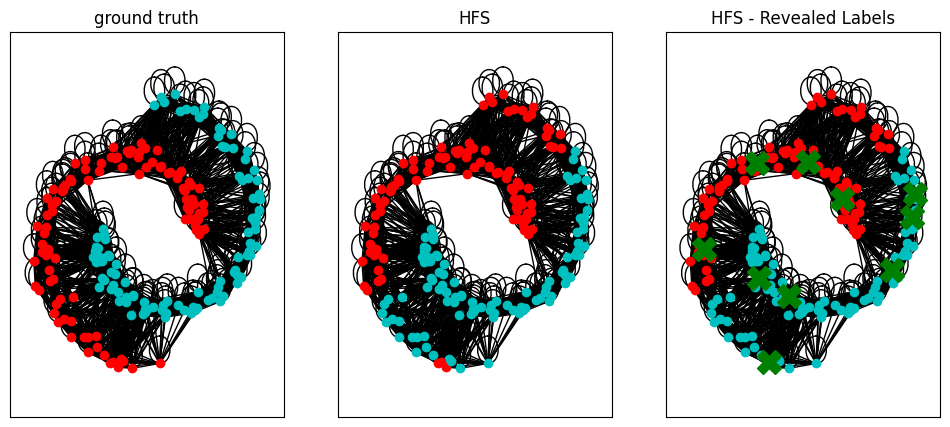

Soft=False, Accuracy=0.825


In [6]:
seed = 42
X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=0, soft=False, dataset='data_2moons_hfs.mat',
                                                 plot=True, seed=seed, **params)

**Comments**

Using hard tresholding HFS, we get an accuracy of $82.5\%$ using only $10$ labeled data.

### Question 1.2  - Using `data_2moons_hfs_large.mat`, run `two_moons_hfs` several times with l=4. What can go wrong?

* Tips:
    * When running `two_moons_hfs` several times, don't forget to set `seed=None`

In [7]:
# np.random.seed(42)
# for ii in range(20):
#     X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=4, l_noisy=0, soft=False, 
#                                                      dataset='data_2moons_hfs_large.mat',
#                                                      plot=False, seed=None, **params)
    
# # mask_labels  # check parameters

**Answer**  
When labels are revealed by masking, it can happen (especially with a small `l`) that all revealed samples come from the same class. In that case, at least one class has no labeled example.  

That is a problem for HFS, because HFS propagates labels from the labeled nodes through the graph. If a class has no starting point, the model has no reliable way to recover that class. In the one-hot target matrix $y \in \mathbb{R}^{n \times C}$, this appears as a null column for that class.  

The solution of the HFS optimization problem becomes ill-posed for that class and predictions can become degenerate.

We can easily solve this issue by passing `per_class=True` as parameter to the `mask_labels` function.

### Question 1.3 - Using `data_2moons_hfs.mat`, l=10 and l_noisy=5, compare hard HFS to soft HFS. Report the accuracy and comment the results.

We do the experiments using $c_l = 1$ and $c_u = 0.01$ and $k=30$. We first try with $\text{seed}=5$ and comments the results, before averaging over several seeds for robustness.

#### Using a single seed

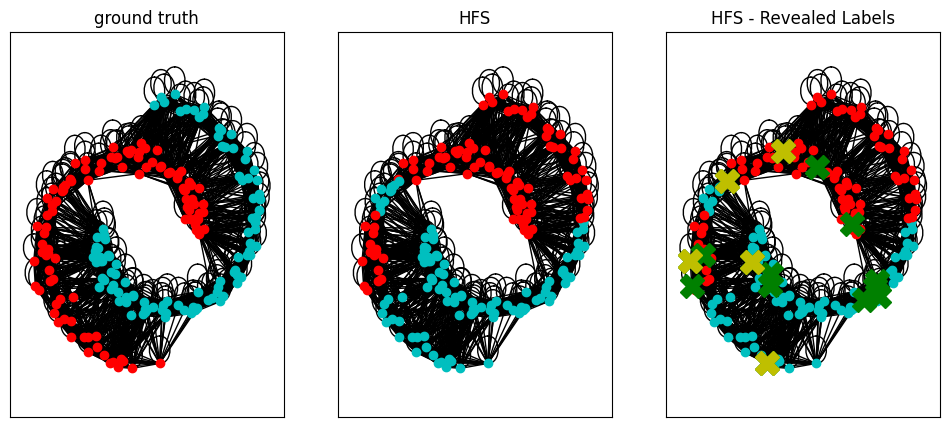

Soft=False, Accuracy=0.695


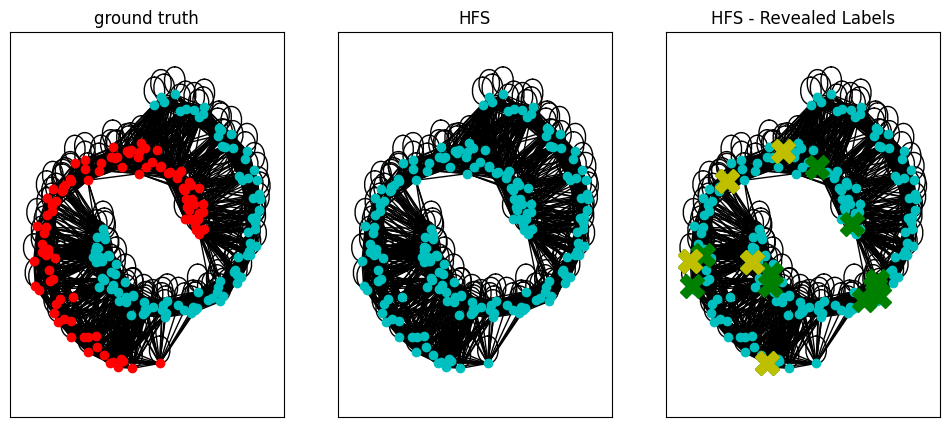

Soft=True, Accuracy=0.5


In [8]:
# Comparing
seed = 5  # To run several times with random outcomes, set seed=None. Otherwise, set a seed for reproducibility.
plot = True 
dataset = 'data_2moons_hfs.mat' # Try also 'data_2moons_hfs_large.mat'


X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset=dataset,
                                                 plot=plot, seed=seed, **params)
X, Y, soft_labels, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset=dataset,
                                                 plot=plot, seed=seed, **params)

**Comments**  

We see that in this run, hard HFS does better than soft HFS. Indeed, the soft HFS algorithm collapses completely, and all the samples are given the same class, even the ones that were revealed as from the other label. This translates the fact that the $C$ matrix is not tunned properly. In contrast, hard HFS is more robust here and keeps useful label information from the revealed nodes.

We try with `data_2moons_hfs_large.mat`

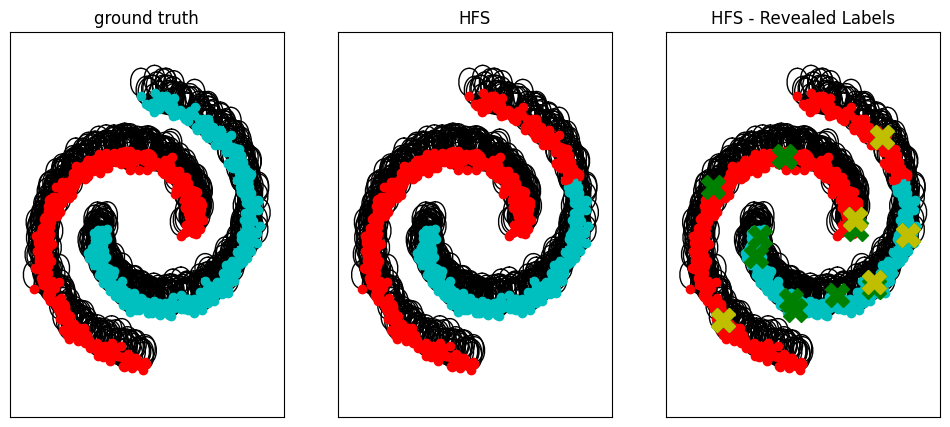

Soft=False, Accuracy=0.886


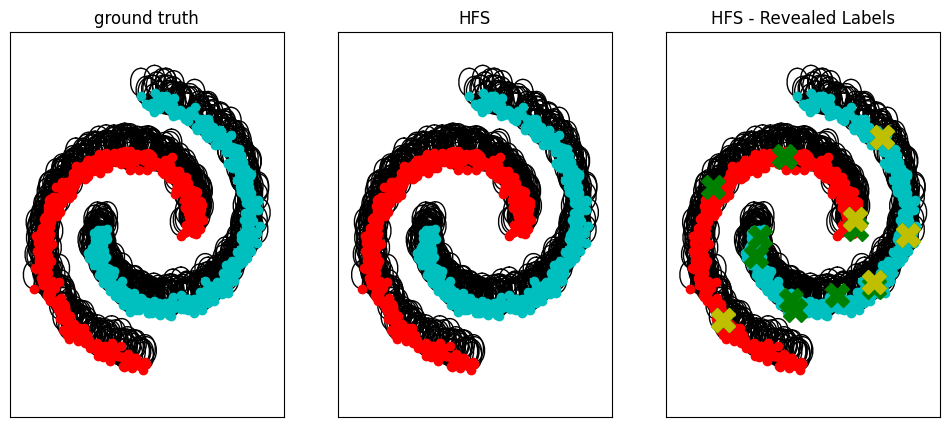

Soft=True, Accuracy=1.0


In [9]:
# Comparing
seed = 5  # To run several times with random outcomes, set seed=None. Otherwise, set a seed for reproducibility.
plot = True 
dataset = 'data_2moons_hfs_large.mat' 

X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset=dataset, plot=plot, seed=seed, **params)
X, Y, soft_labels, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset=dataset, plot=plot, seed=seed, **params)

**Comments**  

In this run soft HFS does better than hard HFS as it reaches 88.6% of accuracy, against 100% for the soft one.

#### For several seeds

On `data_2moons_hfs.mat`

In [10]:
n_seeds = 30
acc_soft_list = []
acc_hard_list = []
plot = False # we do not plot 
for i in range(n_seeds):
    _, _, _, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset='data_2moons_hfs.mat', plot=plot, seed=i, **params)
    _, _, _, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset='data_2moons_hfs.mat', plot=plot, seed=i, **params)
    acc_hard_list.append(hard_accuracy)
    acc_soft_list.append(soft_accuracy)

print(f"Accuracy across {n_seeds} runs:")
print(f"Hard: {np.array(acc_hard_list).mean():.2f} ± {np.array(acc_hard_list).std():.2f}")
print(f"Soft: {np.array(acc_soft_list).mean():.2f} ± {np.array(acc_soft_list).std():.2f}")

Accuracy across 30 runs:
Hard: 0.73 ± 0.10
Soft: 0.53 ± 0.05


Now on `data_2moons_hfs_large.mat`

In [11]:
n_seeds = 30
acc_soft_list = []
acc_hard_list = []
plot = False # we do not plot
for i in range(n_seeds):
    _, _, _, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset='data_2moons_hfs_large.mat', plot=plot, seed=i, **params)
    _, _, _, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset='data_2moons_hfs_large.mat', plot=plot, seed=i, **params)
    acc_hard_list.append(hard_accuracy)
    acc_soft_list.append(soft_accuracy)

print(f"Accuracy across {n_seeds} runs:")
print(f"Hard: {np.array(acc_hard_list).mean():.2f} ± {np.array(acc_hard_list).std():.2f}")
print(f"Soft: {np.array(acc_soft_list).mean():.2f} ± {np.array(acc_soft_list).std():.2f}")

Accuracy across 30 runs:
Hard: 0.89 ± 0.12
Soft: 0.97 ± 0.08


**Comments**

- First, we notice that the standard deviation is larger in both cases for hard HFS than for soft HFS. This confirms our intuition that hard thresholding is less stable and more sensitive to noisy labels.

- We also see that soft HFS can severely underfit on small datasets, whereas it can be very performant on larger datasets. The intuition is that the graph structure is learned more reliably when there are more samples, so we can rely on it to treat noisy labels.


## 2. Face recognition with HFS

Now, we apply HFS to the task of face recognition, that is, our goal is to classify faces as belonging to different people. Since faces all share common features, it can be a good idea to leverage a large quantity of unlabeled data to improve classification accuracy. In this part of the exercise, you will:

* Extract faces from the images using OpenCV for face detection, and use the same library to apply preprocessing steps;
* Run HFS for classification.

### Implementation

Choose the hyperparameters and run HFS for face recognition, using both the small and large dataset. You can try to change the preprocessing steps (e.g. equalizeHist, GaussianBlur) applied to the images.

**Important**: make sure your HFS code is able to handle more than two classes!

### Question 2.1 - How did you manage to label more than two classes?

**Answer**  

To handle more than two classes, I replaced the scalar label vector by a one hot encoded target matrix. Concretely, instead of $y \in \mathbb{R}^n$, I build a matrix $y \in \mathbb{R}^{n \times K}$ where $K$ is the number of classes and $y_{i,k} = 1$ if node $i$ belongs to class $k$, otherwise $0$.

Then HFS is solved with the same equations but in matrix form. For hard HFS, $f_l$ becomes a $(l \times K)$ matrix and the unlabeled scores are computed as

$$
f_u = -L_{uu}^{-1} L_{ul} f_l
$$

so the full solution is $f \in \mathbb{R}^{n \times K}$ where,

$$
f = (L + C)^{-1} C y
$$

Finally, each node is assigned to the class with the largest score

$$
\text{labels}[i] = \argmax_{k \in \{1,\dots,K\}} f_{i,k}
$$


### Question 2.2 - Report the best accuracy you obtained for both (small and augmented) datasets.

* Tips:
    * The small dataset (10 images per person) is loaded with `load_image_data`.
    * Use `load_image_data_augmented` for the augmented dataset (50 images per person). 

### Question 2.3 - If the accuracy changes when using the augmented dataset, explain why. Does using additional data always increase the performance?

**Answer 2.2**  
To be able to obtain the best accuracy for both datasets, we did a small grid search for Soft HFS and obtained the following results and best parameters:

| Dataset | Best accuracy | Best parameters |
|---|---:|---|
| Small | $84\%$ | `{'c_l': 1.0, 'c_u': 0.0001, 'k': 10, 'laplacian_normalization': 'unn', 'laplacian_regularization': 0.01, 'var': 50}` |
| Augmented | $65.4\%$ | `{'c_l': 0.25, 'c_u': 0.0001, 'k': 10, 'laplacian_normalization': 'unn', 'laplacian_regularization': 0.01, 'var': 100}` |

**Answer 3.3**

We see that using additional data in the augmented dataset leads to much worse results, so adding data is not always beneficial. This sharp drop in accuracy between the two datasets can be explained by the following elements.

1. In the `load_image_data_augmented` function, when the face is not detected the fallback is to take the whole image, including background and shoulders. This creates a dataset that does not contain only face crops, and can even include very noisy or blurred images as shown below. These outliers are not present in the original dataset, and they strongly hurt our HFS graph.

2. The ratio of labeled samples drops from $40\%$ on the small dataset to only $8\%$ on the augmented dataset. This makes the SSL task much harder because HFS has far fewer labeled anchor points to propagate labels from. This is likely the main reason for the loss in accuracy.

Looking at the confusion matrices, we also see that on the augmented dataset class 2 is poorly classified. Only about $44\%$ of its samples are correctly labeled, and around $38\%$ are predicted as class 3. When we visualize the class 2 images, many of them are not clean face images but contain a lot of background and shoulders, which explains why this class performs so badly.

In [12]:
import matplotlib.pyplot as plt
from imageio import imread
import numpy as np
import cv2
import os

# We import sklearn for hyperparameter selection
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score # for evaluation after hfs
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

import time # to measure time of execution
from load_images import load_image_data, plot_image_data
from load_images import load_image_data_augmented, plot_image_data_augmented

In [13]:
# Function to preprocess the images
# You may try to change it and check the impact on the classification accuracy
def preprocess_image(image):
    """
    Parameters
    ----------
    image : array
        (width, height) array representing a grayscale image
    
    Returns
    -------
        (96, 96) preprocessed image
    """
    output_frame_size = 96   # do not change the output frame size!
    image = cv2.bilateralFilter(image, 9, 75, 75)
    image = cv2.equalizeHist(image)
    image = cv2.GaussianBlur(image, (5, 5), 0)
    im = cv2.resize(image, (output_frame_size, output_frame_size)).astype(float)
    im -= im.mean()
    im /= im.max()
    image = im
    return image

In [14]:
"""
Define parameters for face recognition with HFS on the small dataset
"""
params_face_rec = {}
params_face_rec["laplacian_regularization"] = 1e-2
params_face_rec["var"] = 50
params_face_rec["eps"] = None
params_face_rec["k"] = 10
params_face_rec["laplacian_normalization"] = "unn"
params_face_rec["c_l"] = 1.0
params_face_rec["c_u"] = 1e-4


In [15]:
"""
Define parameters for face recognition with HFS on the augmented dataset
"""
params_face_rec_a = {}
params_face_rec_a["laplacian_regularization"] = 1e-2
params_face_rec_a["var"] = 100
params_face_rec_a["eps"] = None
params_face_rec_a["k"] = 10
params_face_rec_a["laplacian_normalization"] = "unn"
params_face_rec_a["c_l"] = 0.25
params_face_rec_a["c_u"] = 1e-4


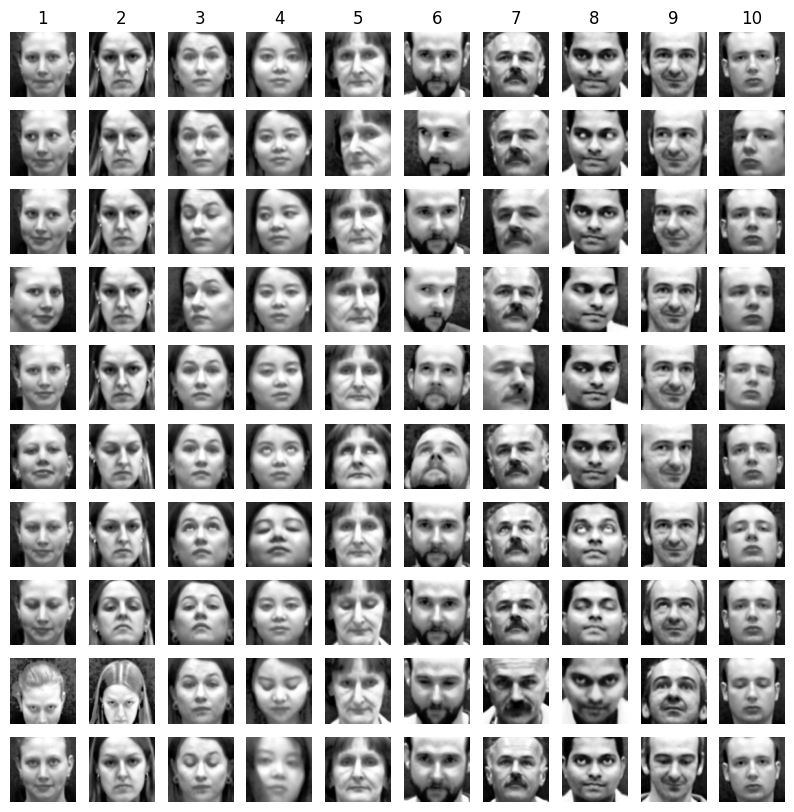

Ratio of labeled samples: 40.00%


In [16]:
# # 10 images per person
np.random.seed(456)   # set seed, since labels are masked randomly
images, labels, masked_labels = load_image_data(preprocess_image)
plot_image_data(images)
print(f"Ratio of labeled samples: {(1 -np.mean(masked_labels == 0))*100:.2f}%")

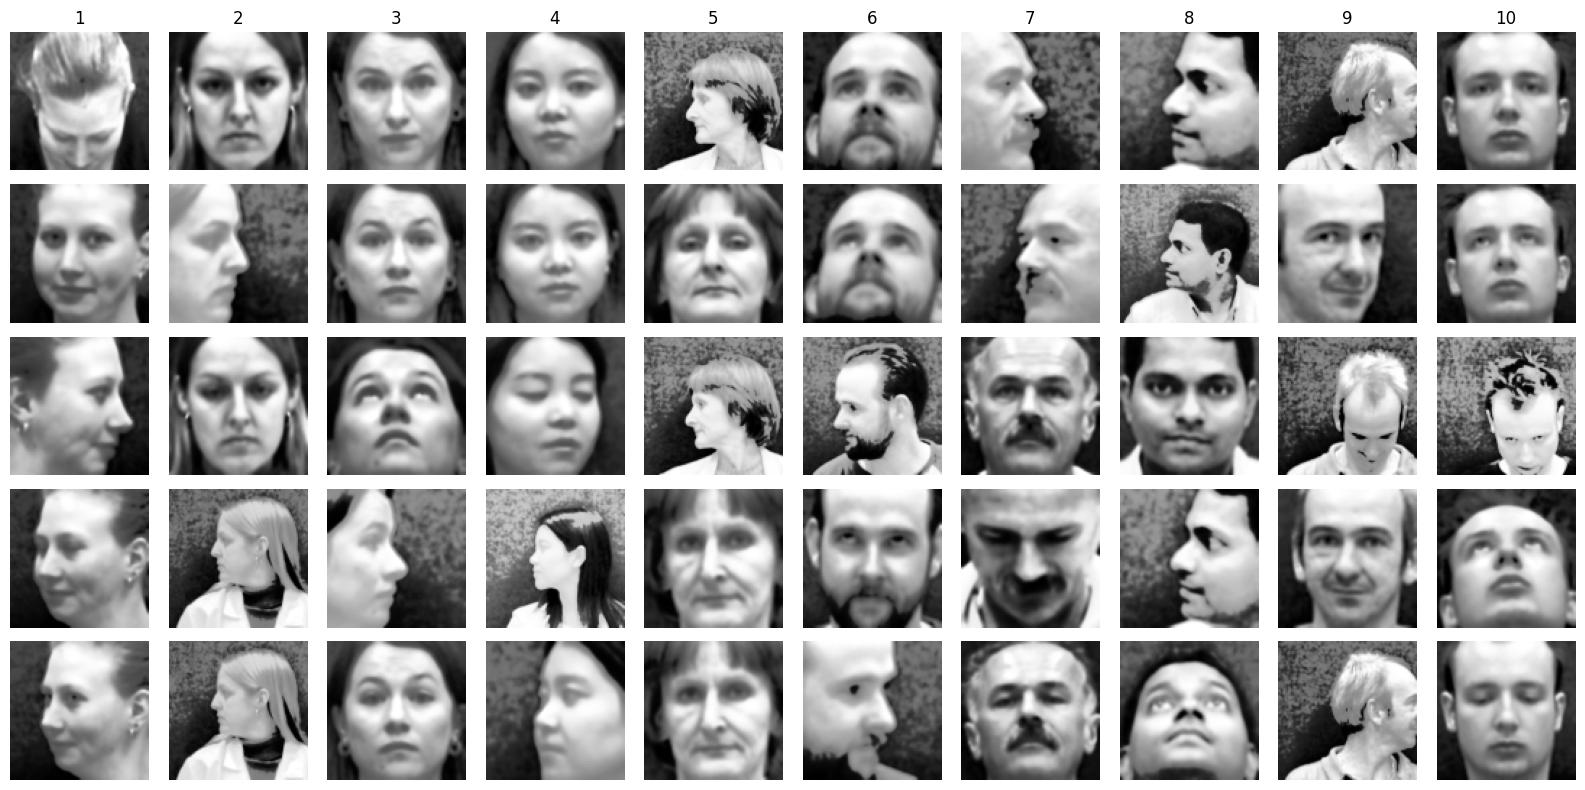

Ratio of labeled samples for the augmented dataset: 8.00%


In [17]:
# 50 images per person
np.random.seed(456)   # set seed, since labels are masked randomly
images_a, labels_a, masked_labels_a = load_image_data_augmented(preprocess_image)
plot_image_data_augmented(images_a)
print(f"Ratio of labeled samples for the augmented dataset: {(1 - np.mean(masked_labels_a == 0))*100:.2f}%")

Example of a non face image on the augmented dataset

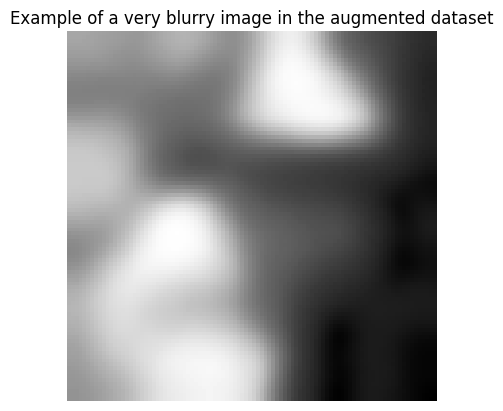

In [18]:
non_face = images_a[400].reshape(96, 96)
plt.imshow(non_face, cmap='gray')
plt.title("Example of a very blurry image in the augmented dataset")
plt.axis('off')
plt.show()  

In [19]:
# graph Laplacian
L = build_laplacian_regularized(images, 
                                params_face_rec['laplacian_regularization'], 
                                params_face_rec['var'], 
                                params_face_rec['eps'], 
                                params_face_rec['k'], 
                                params_face_rec['laplacian_normalization'])

# graph Laplacian for the augmented dataset
L_a = build_laplacian_regularized(images_a, 
                                params_face_rec_a['laplacian_regularization'], 
                                params_face_rec_a['var'], 
                                params_face_rec_a['eps'], 
                                params_face_rec_a['k'], 
                                params_face_rec_a['laplacian_normalization'])


# Run HFS
predicted_labels, f = compute_hfs(L, masked_labels, soft=True, **params_face_rec)
accuracy = np.equal(predicted_labels, labels).mean()

predicted_labels_a, f_a = compute_hfs(L_a, masked_labels_a, soft=True, **params_face_rec_a)
accuracy_a = np.equal(predicted_labels_a, labels_a).mean()

print(f"Accuracy on the small dataset = {accuracy:.2f}")
print(f"Accuracy on the augmented dataset = {accuracy_a:.2f}")


Accuracy on the small dataset = 0.84
Accuracy on the augmented dataset = 0.65


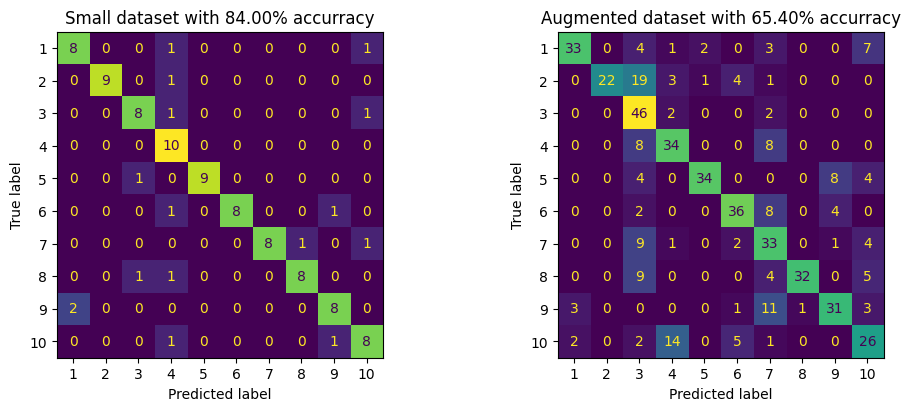

In [20]:
# Compute and display confusion matrices for both datasets
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ConfusionMatrixDisplay(
    confusion_matrix(labels, predicted_labels, labels=np.arange(1, 11)),
    display_labels=np.arange(1, 11)
).plot(ax=ax[0], colorbar=False)
ax[0].set_title(f"Small dataset with {accuracy*100:.2f}% accurracy")

ConfusionMatrixDisplay(
    confusion_matrix(labels_a, predicted_labels_a, labels=np.arange(1, 11)),
    display_labels=np.arange(1, 11)
).plot(ax=ax[1], colorbar=False)
ax[1].set_title(f"Augmented dataset with {accuracy_a*100:.2f}% accurracy")
plt.show()



Visualization of all images belonging to class 2 in the augmented dataset, to try to identify why the results are so bad for this class.

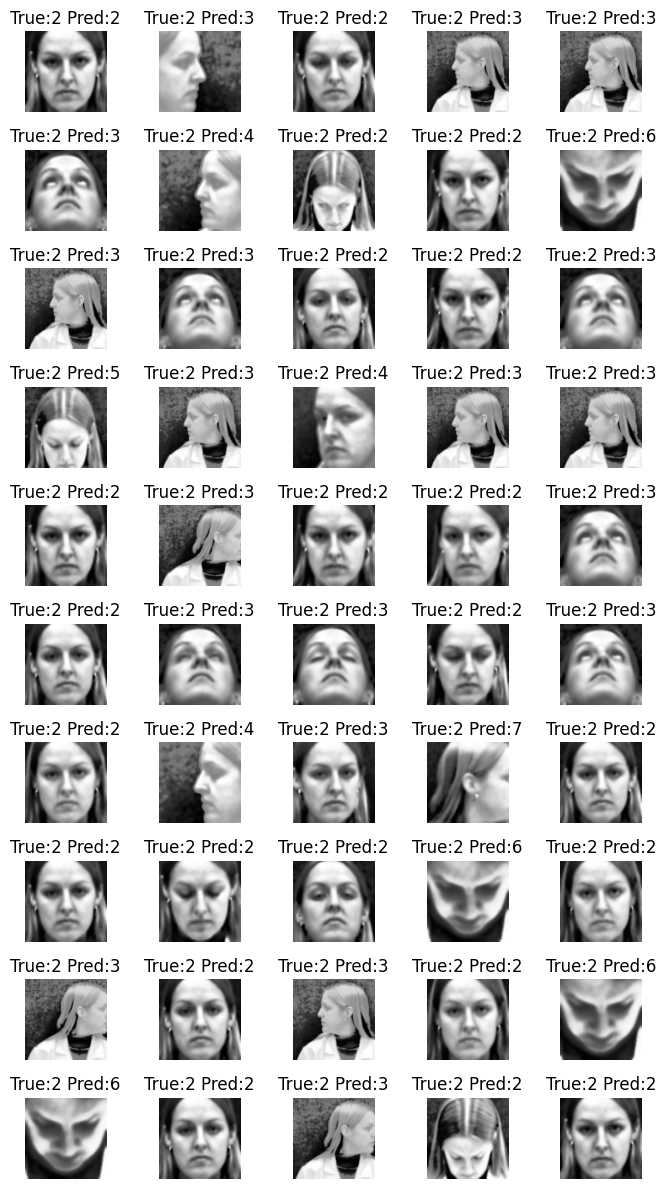

In [21]:
idx = np.where(labels_a.reshape(-1) == 2)[0] # get indices of samples belonging to class 2

plt.figure(figsize=(7,12))
for j, i in enumerate(idx[:50]):
    plt.subplot(10, 5, j + 1)
    plt.imshow(images_a[i].reshape(96, 96), cmap="gray")
    plt.title(f"True:{labels_a[i]} Pred:{predicted_labels_a[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

We clearly see that there is a lot of non-face images for this class, that could explain the bad accuracy results for this class.

## 3. Online SSL

Now, instead of having all the data available at once, images will be received online: at each time $t$, a new image $x_t$ is observed and the algorithm has to output a label $y_t$. 

Use the function `create_user_profile` to capture a training set of labeled data (of your face and someone else). The faces will be preprocessed and saved in the folder `data/faces`. They will be loaded by `online_face_recognition`.


### Implementation

Choose the hyperparameters and complete the functions `online_ssl_update_centroids` and `online_ssl_compute_solution`. 

Modify your code to be able to disregard faces it cannot recognize.

* Tips:
    * You can use the functions `build_similarity_graph` and `build_laplacian`.

### Question 3.1 - Attach to this notebook some of the resulting frames of online face recognition. 

* Tips: 
    * You can save the resulting frame and add it to the notebook in a markdown cell as `![title](picture.png)`

**Answer 3.1**  
I have chosen a short sequence of the film *Good Will Hunting*, where two characters appear (*Will Hunting* and *Sean*) to do this online face recognition task. Then, for question 4, we also introduce a new character (*Minnie*) to treat unknown faces. See below two examples of the online face recognition task.

![Will Hunting](results\will.png)

![Sean](results\sean.png)

### Question 3.2 - What strategy did you use to label a face as unknown? Attach to this notebook an example of a unknown face being correctly labeled as unknown.

* Tips
    * If you identify a face as unknown, you can return `[("unknown", score)]` from the function `online_ssl_compute_solution`.

**Answer 3.2**  
To decide whether a face $x_t$ should be labeled as unknown, I used a confidence based rule on the HFS output. The HFS solution gives a score for every known label in a vector $f(x_t)$. If the maximum probability over all known labels is below a fixed threshold, I label the face as unknown and return  
`[("unknown", 1.0)]`.

When running `online_face_recognition('Sean', 'Will Hunting')`, we get that *Minnie* is labeled as unknown as seen below.


![Minnie](results\minnie.png)

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import os
import sys
from scipy.spatial import distance
import scipy.io as sio

from helper_online_ssl import create_user_profile, online_face_recognition

In [23]:
"""
Define parameters for face recognition with HFS
"""
params_online_ssl = {}
params_online_ssl["laplacian_regularization"] = 1e-2
params_online_ssl["var"] = 100
params_online_ssl["eps"] = None
params_online_ssl["k"] = 10
params_online_ssl["laplacian_normalization"] = "unn"

In [24]:
class IncrementalKCenters:
    def __init__(self, labeled_faces, labels, label_names, max_num_centroids=50):
        #  Number of labels
        self.n_labels = max(labels)

        #  Dimension of the input image
        self.image_dimension = labeled_faces.shape[1]

        #  Check input validity
        assert (set(labels) == set(
            range(1, 1 + self.n_labels))), "Initially provided faces should be labeled in [1, max]"
        assert (len(labeled_faces) == len(labels)), "Initial faces and initial labels are not of same size"

        #  Number of labelled faces
        self.n_labeled_faces = len(labeled_faces)

        # Model parameter : number of maximum stored centroids
        self.max_num_centroids = max_num_centroids

        # Model centroids (inital labeled faces). Shape = (number_of_centroids, dimension)
        self.centroids = labeled_faces

        # Centroids labels
        self.Y = labels
        
        # Label names (= user names)
        self.label_names = label_names

        # Variables that are initialized in online_ssl_update_centroids()
        self.centroids_distances = None
        self.taboo = None
        self.V = None
        self.init = True

        # index of x_t (initialized later)
        self.last_face = None

        # Answer to 4.1
        self.auto_label_min_count = 10 # minimum number of time a face should be seen to be labelled automatically

    
    def initialize(self):
        """
        Initialization after the first time that the maximum number of centroids is reached.
        """       
        #  Compute the centroids distances
        self.centroids_distances = distance.cdist(self.centroids, self.centroids)

        #  set labeled nodes and self loops as infinitely distant, to avoid merging labeled centroids
        np.fill_diagonal(self.centroids_distances, np.inf)
        self.centroids_distances[0:self.n_labeled_faces, 0:self.n_labeled_faces] = np.inf

        # put labeled nodes in the taboo list
        self.taboo = np.array(range(self.centroids.shape[0])) < self.n_labeled_faces

        # initialize multiplicity
        self.V = np.ones(self.centroids.shape[0])


    def online_ssl_update_centroids(self, face):
        """
        TO BE COMPLETED

        Update centroids, multiplicity vector V, labels Y.
        
        Note: In Y, set label to 0 for unlabeled faces.

        Parameters
        ----------
        face : array
            New sample
        
        Returns
        --------
        List with the scores for each possible label:
            [(label_1, score_1), (label_2, score_2), ...]
        """

        assert (self.image_dimension == len(face)), "new image not of good size"

        # Case 1: maximum number of centroids has been reached.
        if self.centroids.shape[0] >= self.max_num_centroids + 1:
            if self.init:
                #  Initialization after the first time that the maximum number of centroids is reached
                self.initialize()
                self.init = False
            """
            Find c_rep and c_add following Algorithm 1.
            
            - c_1, c_2 = two closest centroids (minimum distance) such that at least one of them is not in self.taboo.
            - c_rep = centroid in {c_1, c_2} that is in self.taboo. If none of them is in self.taboo, c_rep is the one
                      with largest multiplicity.
            - c_add = centroid in {c_1, c_2} that is not c_rep.
            """
            # Find c_1 and c_2
            dist = self.centroids_distances.copy()
            dist[np.ix_(self.taboo, self.taboo)] = +np.inf # avoid c1 and c2 being both in the taboo list

            c1, c2 = np.unravel_index(np.argmin(dist), dist.shape)

            # Find c_rep and c_add as done in the algorithm 1
            if self.taboo[c1]:  # if c1 in taboo list
                c_rep = c1
                c_add = c2
            elif self.taboo[c2]:  # if c2 in taboo list
                c_rep = c2
                c_add = c1
            # if nether is in the taboo list, choose c_rep as the one with highest multiplicity
            elif self.V[c2] <= self.V[c1]:
                c_rep = c1
                c_add = c2
            else: # V[c2] > V[c1] 
                c_rep = c2
                c_add = c1 

            """
            Update data structures: self.centroids and self.V
            """
            self.V[c_rep] += self.V[c_add] # update the multiplicty vector
            self.centroids[c_add, :] = face # set the new centroid as the new face
            self.V[c_add] = 1 # new centroid multiplicity
            self.Y[c_add] = 0 # new centroid is unlabeled, so we set its label to 0
            self.taboo[c_add] = False # new centroid is not in the taboo list, since it is not labeled
            
            # Answer 4.1, labeling unknown faces
            merge_threshold = 45.0 # tunned by looking at d_min values
            tab = self.taboo.copy()
            tab[c_rep] = False
            d_min = self.centroids_distances[c_rep, tab].min() if tab.any() else np.inf # we only label new centroids if the closest labeled centroid is far enough
            # print(d_min)
            # Labeling off faces that have been seen at least auto_label_min_count times, and that are not in the taboo list yet
            if (d_min >= merge_threshold) and (not self.taboo[c_rep]) and (self.V[c_rep] >= self.auto_label_min_count):

                new_label = self.n_labels + 1 # assign new label
                self.n_labels = new_label # update the number of labels

                self.Y[c_rep] = new_label 
                self.taboo[c_rep] = True
                
                self.label_names.append(f"Auto_{new_label}")

            """
            Update the matrix containing the distances.
            """
            dist_row = distance.cdist(np.array([self.centroids[c_add]]), self.centroids)[0]
            dist_row[c_add] = +np.inf
            self.centroids_distances[c_add, :] = dist_row
            self.centroids_distances[:, c_add] = dist_row
            self.last_face = c_add

        # Case 2: create new centroid with face
        # Remark: the multiplicities vector self.V is initialized in self.initialize()
        else:
            current_len = len(self.centroids)
            self.Y = np.append(self.Y, 0)
            self.centroids = np.vstack([self.centroids, face])

    def online_ssl_compute_solution(self):
        """
        TO BE COMPLETED.

        Returns a prediction corresponding to self.last_face.
        """

        # Multiplicity matrix
        if self.init:
            V = np.diag(np.ones(self.centroids.shape[0]))
            self.last_face = self.centroids.shape[0] - 1
        else:
            V = np.diag(self.V)
            
        # Build quantized graph and its regularized Laplacian
        W = build_similarity_graph(self.centroids, var = params_online_ssl['var'],
                                   k = params_online_ssl['k']) # weights matrix of the quantized graph
        Wq = V @ W @ V # take into account centroids multiplicity
        L = build_laplacian(Wq, laplacian_normalization=params_online_ssl['laplacian_normalization']) # laplacian
        Q = L + params_online_ssl['laplacian_regularization']*np.eye(L.shape[0]) # regularized Laplacian

        # Compute the hard HFS solution f. 
        labels, f = compute_hfs(Q, self.Y, soft=False, **params_online_ssl)

        # print(f.shape)
        # Return the score for each possible label
        num_classes = len(np.unique(self.Y))-1 
        label_scores = []
        for ii in range(num_classes):
            label = self.label_names[ii]
            score = f[self.last_face, ii]
            label_scores.append((label, score))
        
        # print(f"f[self.last_face]: {f[self.last_face, :]}, label_scores: {label_scores}")
        # handle unknown faces
        treshold = 0.5 # arbitrary treshold
        scores = np.array([score for _, score in label_scores], dtype=float)
        max_label_score = max(scores) # we look at the maximum score among the labels, and if it is smaller than a treshold, we classify as unknown

        if max_label_score < treshold:
            label_scores = [("unknown", 1.0)]
        return label_scores
      


In [25]:
# create_user_profile('Sean', video_filename='data\will_hunting_1.mp4')
# create_user_profile('Will Hunting', video_filename='data\will_hunting_1.mp4')
# create_user_profile('Minnie', video_filename='data\will_hunting_2.mp4')
# online_face_recognition(['Will Hunting'], IncrementalKCenters, n_pictures=15, video_filename='data\will_hunting_2.mp4')

### Question 4.1 - You can now classify faces as either known (i.e. belong to a class) or unknown (i.e. belong to no class). How would you modify the algorithm to automatically learn to classify new classes? That is, how can you modify the algorithm so that faces that appear unfrequently are labeled as unknown, but once a specific face has been seen enough times it gets assigned an automatic label (e.g. AutoBob) and from that point it is treated as a new class. 

* Tips: 
    * Think back to the idea of incremental clustering as unsupervised classification

**Answer 4.1**  

- First it is important to state that in practice, the OpenCV face detector is not very reliable. The bounding box can be slightly off, faces can be missed, and sometimes we crop background or partial faces. This adds noise in the face vectors and it can strongly degrade the online recognition, because the incremental centroids and the graph propagation are then built on corrupted samples.

- To automatically learn new classes, we extend the incremental $k$ centers idea. Unlabeled faces are first treated as unknown by the method previously stated. Then, when an unlabeled centroid becomes frequent enough, meaning that its multiplicity in the `V` vector is above a threshold, we assign it to a new class with name `Auto_k`. From that moment, it is treated like a labeled class and can propagate its label to similar future faces. Here, $k$ starts at `n_labels + 1` in my implementation.  

- To avoid creating many labels for the same person, we add a second condition. Before promoting a centroid, we compute its distance to the closest already labeled centroid. If this distance is too small, we do not create a new label, because it likely corresponds to an existing identity. Even with this rule, the same face can still be automatically labeled multiple times, because variations in cropping, pose, and lighting can create several frequent but distinct clusters. So the distance test helps but is not sufficient on its own when we try it in practice.

This resembles unsupervised classification because we are essentially doing online clustering in the embedding space.

**Hyperparameters**

This method uses two thresholds, one for frequency and one for distance.

* `auto_label_min_count = 10`  
This controls how many times a face must appear before we create a new automatic label. The user can choose it depending on how fast they want new faces to be labeled.

* `merge_threshold`  
This is harder to tune. It is the minimum distance $d_{\min}$ to the closest already labeled centroid required to create a new class. We set it to $45$ by looking at typical values of $d_{\min}$ during our runs.


Here is an example of an image, where *Minnie* is first labeled unknown, and then automatically labeled when running `online_face_recognition("Will Hunting")`. She is labeled automatically `Auto_2` since we ran our algorithm with one labeled face corresponding to `Will Hunting`.

![auto_labelling](results\auto_labelling.png)

### Question 4.2 - In class we considered different kinds of metric for (semi) supervised learning. Looking at the face classification task, try to quantify how the offline-online, exact-quantized, and inductive-transductive axes influence each other. In particular given $l$ labeled faces, $u = N - l$ unlabeled faces, and $m$ extra/test faces design an experimental study to quantify these trade-offs, both in terms of transductive and inductive error, as well as online/batch error. Examples of combinations that can be used to study these axes are:
* Supervised vs Semi-supervised
    * A comparison between a supervised learner (of your choice) trained on the $l$ labeled faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces.
* Inductive vs Transductive
    * A comparison between a supervised learner (of your choice) trained on the $l$ labeled faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces evaluated on the $N$ revealed points and then on the $m$ unrevealed points.
* Supervised vs Semi-supervised and Inductive vs Transductive
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces, evaluated on the $N$ revealed points and then on the $m$ unrevealed points.
* Online vs Batch
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled faces and an online supervised learner (of your choice) trained revealing the $N$ labels one at a time
* Exact vs Quantized
    * A comparison between a semi-supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces using a certain memory budget, and the same learner with a constrained memory budget.
* Exact vs Quantized and Online vs Batch and Inductive vs Transductive
    * A comparison between a semi-supervised online learner (of your choice) trained with and without quantization, evaluated both on the $N$ faces revealed during training, and $m$ faces unrevealed. You can further compare the online performance of the learner against the performance of an "hindsight" learner that saw the labels all at once

**Answer 4.2**  

I have chosen to develop the supervised vs semi-supervised and inductive vs transductive axis. We implemented an experimental study to compare a supervised learner and a semi-supervised graph based learner on the face recognition task. We train both methods with only $l$ labeled faces per class, and we also use the $u$ remaining faces without labels for semi-supervised learning.

**Choice of the dataset**

We choose the augmented faces dataset, that we have seen contains blurry and non-faces images. The augmented dataset allow us to compare how robust each learner is to these perturbations. It is interressant since we saw that in practice the Open-CV framing was not perfect.

**Learners and evaluation protocol**

- For the supervised baseline, we use a nearest class mean (NCM) classifier trained only on the $l$ labeled faces. Indeed, we compute for each labeled class a prototype, and then for each new sample, we assign its label as its closest prototype. 

- For the semi-supervised method, we use hard HFS on a similarity graph built on the $N$ revealed faces. This method is transductive because it predicts labels for the unlabeled nodes that are part of the graph.

To evaluate inductively on $m$ unrevealed faces, we implement an out of sample extension for HFS. After computing the HFS score matrix $f$ on the $N$ revealed faces, each new test face is connected to the revealed set by computing similarity. We then compute its score vector as a similarity weighted average of the $N$ scores. This produces a prediction for the $m$ test faces while keeping the training procedure unchanged.

We give below both the inductive and transductive accuracy of each method.

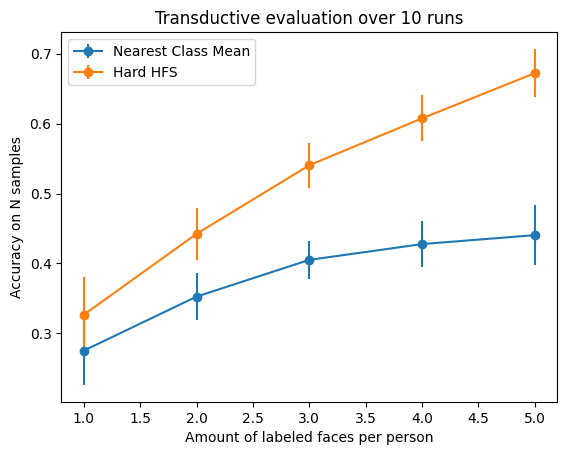

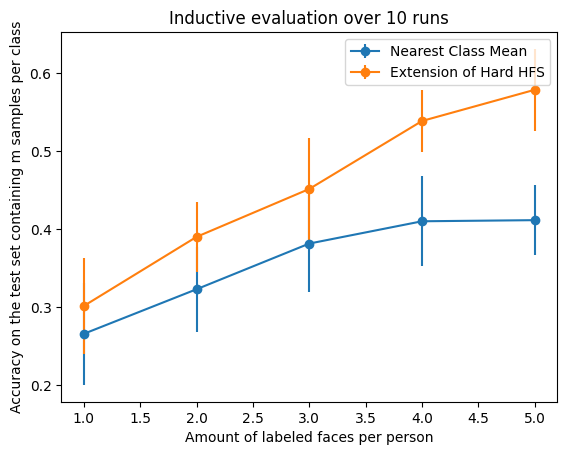

In [26]:
# Function to split the data into train and test sets, with m_per_class samples per class in the test
def split_train_test_per_class(X, y, m_per_class=2, seed=0):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    test_idx = []
    # for each class, we randomly select m_per_class samples to be in the test set
    for c in classes:
        idx_c = np.where(y == c)[0]
        idx_c = rng.permutation(idx_c)
        test_idx.extend(idx_c[:m_per_class].tolist())
    test_idx = np.array(test_idx, dtype=int)
    
    # we build the train_idx as the complement of test_idx
    train_mask = np.ones(len(y), dtype=bool)
    train_mask[test_idx] = False
    train_idx = np.where(train_mask)[0]

    return train_idx, test_idx


# Function to pick l_per_class labeled samples per class in the training set
def pick_l_labeled_per_class(y_train, l_per_class=2, seed=0):
    rng = np.random.default_rng(seed)
    classes = np.unique(y_train)
    labeled_idx = []
    for c in classes:
        idx_c = np.where(y_train == c)[0]
        idx_c = rng.permutation(idx_c)
        labeled_idx.extend(idx_c[:l_per_class].tolist())
    return np.array(labeled_idx, dtype=int)

# Function that computes the prototypes on the training set
def ncm_train(X_train, y_train, labeled_idx):
    classes = np.unique(y_train[labeled_idx])
    means = []
    for c in classes:
        means.append(X_train[labeled_idx][y_train[labeled_idx] == c].mean(axis=0))
    means = np.vstack(means)
    return means, classes

# Function that predicts the labels of X given the prototypes means and their classes, after using the ncm_train function
def ncm_predict(X, means, classes):
    d2 = ((X[:, None, :] - means[None, :, :]) ** 2).sum(axis=2) # compute squared distances to the prototypes
    return classes[np.argmin(d2, axis=1)] # assign the label of the closest prototype to each sample

# Function that computes the hard HFS solution on the training set
def hfs_fit_predict(X_train, Y_masked, params):
    W = build_similarity_graph(X_train, var=params["var"], eps=params["eps"], k=params["k"])
    L = build_laplacian(W, laplacian_normalization=params["laplacian_normalization"])
    Q = L + params["laplacian_regularization"] * np.eye(L.shape[0])
    labels_pred, f = compute_hfs(Q, Y_masked, soft=False)
    return labels_pred.astype(int), f

# Function that extends the HFS solution on one new point, so that we can evalute on the m test samples
def hfs_extend_one(x_new, X_train, f_train, var, k_ext=20):
    d2 = ((X_train - x_new[None, :]) ** 2).sum(axis=1)
    w = np.exp(-d2 / var) # new similarity

    if k_ext is not None and k_ext < len(w): # keep only the k_ext closest neighbors
        keep = np.argpartition(-w, k_ext)[:k_ext]
        w2 = np.zeros_like(w)
        w2[keep] = w[keep] 
        w = w2

    s = w.sum()
    if s <= 1e-12: # if the new point is very far for the other points, we return the unweighted average since the weights are all too small 
        return f_train.mean(axis=0)

    return (w[:, None] * f_train).sum(axis=0) / s # weighted average of the neighbors f values

# Function that runs the whole study for different values of l_per_class
def run_study(l_values, m_per_class=2, seeds=10, params=None):
    X, y_true, _ = load_image_data_augmented() # use augmented dataset 
    y_true = y_true.astype(int)
    
    # Split our dataset
    train_idx, test_idx = split_train_test_per_class(X, y_true, m_per_class=m_per_class, seed=0)
    X_train, y_train = X[train_idx], y_true[train_idx]
    X_test, y_test = X[test_idx], y_true[test_idx]

    out = {}
    out["sup_trans"] = []
    out["sup_ind"] = []
    out["ssl_trans"] = []
    out["ssl_ind"] = []

    for l_per_class in l_values:
        sup_trans_list = []
        sup_ind_list = []
        ssl_trans_list = []
        ssl_ind_list = []

        for s in range(seeds):
            labeled_local = pick_l_labeled_per_class(y_train, l_per_class=l_per_class, seed=s)

            Y_masked = np.zeros_like(y_train)
            Y_masked[labeled_local] = y_train[labeled_local] # mask the labels, only keeping l_per_class labeled samples per class
            
            # First method: supervised learning with Nearest Class Mean classifier 
            means, classes = ncm_train(X_train, y_train, labeled_local)
            yhat_train_sup = ncm_predict(X_train, means, classes)
            yhat_test_sup = ncm_predict(X_test, means, classes)

            sup_trans_list.append((yhat_train_sup == y_train).mean())
            sup_ind_list.append((yhat_test_sup == y_test).mean())

            # Second method : semi-supervised learning with hard HFS
            yhat_train_ssl, f_train = hfs_fit_predict(X_train, Y_masked, params)

            ssl_trans_list.append((yhat_train_ssl == y_train).mean())

            f_test = np.vstack([hfs_extend_one(x, X_train, f_train, var=params["var"], k_ext=20) for x in X_test])
            yhat_test_ssl = np.argmax(f_test, axis=1) + 1
            ssl_ind_list.append((yhat_test_ssl == y_test).mean())

        out["sup_trans"].append((np.mean(sup_trans_list), np.std(sup_trans_list)))
        out["sup_ind"].append((np.mean(sup_ind_list), np.std(sup_ind_list)))
        out["ssl_trans"].append((np.mean(ssl_trans_list), np.std(ssl_trans_list)))
        out["ssl_ind"].append((np.mean(ssl_ind_list), np.std(ssl_ind_list)))

    return out


# Parameters for the HFS function, we keep the same as in the previous part
params_hfs = {}
params_hfs["var"] = 100.0
params_hfs["eps"] = 0.0
params_hfs["k"] = 10
params_hfs["laplacian_normalization"] = "unn"
params_hfs["laplacian_regularization"] = 1e-2

n_runs = 10
l_values = [1, 2, 3, 4, 5]
res = run_study(l_values, m_per_class=7, seeds=n_runs, params=params_hfs) # test set containing 70 images among 500 total images

x = np.array(l_values)

sup_trans_mu = np.array([m for m, s in res["sup_trans"]])
sup_trans_sd = np.array([s for m, s in res["sup_trans"]])
ssl_trans_mu = np.array([m for m, s in res["ssl_trans"]])
ssl_trans_sd = np.array([s for m, s in res["ssl_trans"]])

sup_ind_mu = np.array([m for m, s in res["sup_ind"]])
sup_ind_sd = np.array([s for m, s in res["sup_ind"]])
ssl_ind_mu = np.array([m for m, s in res["ssl_ind"]])
ssl_ind_sd = np.array([s for m, s in res["ssl_ind"]])

# We plot the transductive and inductive accuracies for both methods and several runs
plt.figure()
plt.errorbar(x, sup_trans_mu, yerr=sup_trans_sd, marker="o", label="Nearest Class Mean")
plt.errorbar(x, ssl_trans_mu, yerr=ssl_trans_sd, marker="o", label="Hard HFS")
plt.xlabel("Amount of labeled faces per person")
plt.ylabel("Accuracy on N samples")
plt.title(f"Transductive evaluation over {n_runs} runs")
plt.legend()
plt.show()

plt.figure()
plt.errorbar(x, sup_ind_mu, yerr=sup_ind_sd, marker="o", label="Nearest Class Mean")
plt.errorbar(x, ssl_ind_mu, yerr=ssl_ind_sd, marker="o", label="Extension of Hard HFS")
plt.xlabel("Amount of labeled faces per person")
plt.ylabel("Accuracy on the test set containing m samples per class")
plt.title(f"Inductive evaluation over {n_runs} runs")
plt.legend()
plt.show()

We clearly see that the semi-supervised method outperforms the supervised one in both transductive and inductive accuracy. We note that NCM is a very simple baseline, and the supervised results could likely be improved by using a stronger classifier.
